# Preparing the multi-omic data

This notebook reads, quality-checks, and lightly cleans the two datasets this project builds on: paired transcriptome and proteome profiles from a cohort of diffuse large B-cell lymphoma (DLBCL) patients, stored as a MuData object, and proteome profiles from an independent colorectal cancer (CRC) cohort, stored as a CSV file. The result is a cleaned, matrix-ready version of each dataset, saved at the end for the benchmarking notebook that follows.

### Environment check

In [1]:
# --- Cell 1: environment check / install --------
import importlib.util
import subprocess
import sys


def ensure(pkg: str, import_name: str | None = None):
    name = import_name or pkg
    if importlib.util.find_spec(name) is None:
        print(f"installing {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])
    else:
        print(f"{pkg} already installed")


for pkg, mod in [
    ("mudata", "mudata"),
    ("anndata", "anndata"),
    ("h5py", "h5py"),
    ("pandas", "pandas"),
    ("numpy", "numpy"),
    ("matplotlib", "matplotlib"),
]:
    ensure(pkg, mod)

mudata already installed
anndata already installed
h5py already installed
pandas already installed
numpy already installed
matplotlib already installed


### Imports

In [2]:
# --- Cell 2: imports -----------
import json
import os
from importlib.metadata import version as pkg_version
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import mudata as mu
import numpy as np
import pandas as pd

mu.set_options(pull_on_update=False)

for _pkg in ["mudata", "anndata", "pandas"]:
    print(_pkg, pkg_version(_pkg))

mudata 0.3.10
anndata 0.12.19
pandas 2.3.3


### Locating the raw data

In [3]:
# --- Cell 3: locate the data —------

try:
    THIS_DIR = Path(__file__).resolve().parent
except NameError:
    THIS_DIR = Path.cwd()

BASE_DIR = (THIS_DIR / "..").resolve()

DLBCL_FILENAME = "mudata_union.h5mu"
CRC_FILENAME = "normalized_normics_vsn_log2_bid_only_plate_corrected_limma.csv"

# Search order: to locate where my data dir
CANDIDATE_DATA_DIRS = [
    Path("/projects/datasets_BIO/reuben_imputation"),  # my data dir
    BASE_DIR / "data",
    BASE_DIR,
    Path.home() / "data",
]


def resolve_data_file(filename: str, env_var: str) -> Path:
    override = os.environ.get(env_var)
    if override:
        p = Path(override).expanduser().resolve()
        if not p.exists():
            raise FileNotFoundError(f"${env_var} points to {p}, but it doesn't exist")
        return p

    searched = []
    for d in CANDIDATE_DATA_DIRS:
        if not d.exists():
            searched.append(f"{d}  (dir not found)")
            continue

        direct = (d / filename).resolve()
        if direct.exists():
            return direct

        matches = sorted(d.rglob(filename))
        if matches:
            if len(matches) > 1:
                print(
                    f"warning: multiple copies of {filename!r} found under {d}, "
                    f"using the first: {matches[0]}\n  all matches: {matches}"
                )
            return matches[0].resolve()

        searched.append(f"{d}  (checked directly + subfolders)")

    raise FileNotFoundError(
        f"couldn't find {filename!r}. Looked in:\n  " + "\n  ".join(searched) + "\n"
        f"Fix by either exporting {env_var}=/full/path/to/{filename}, "
        f"or adding its directory to CANDIDATE_DATA_DIRS above."
    )


DLBCL_MUDATA_PATH = resolve_data_file(DLBCL_FILENAME, "DLBCL_MUDATA_PATH")
CRC_PROTEOMICS_CSV_PATH = resolve_data_file(CRC_FILENAME, "CRC_PROTEOMICS_CSV_PATH")

print("DLBCL mudata:", DLBCL_MUDATA_PATH)
print("CRC proteomics csv:", CRC_PROTEOMICS_CSV_PATH)

DLBCL mudata: /projects/datasets_BIO/reuben_imputation/mudata_union.h5mu
CRC proteomics csv: /projects/datasets_BIO/reuben_imputation/normalized_normics_vsn_log2_bid_only_plate_corrected_limma.csv


### Helpers

Two small helpers, defined once and used consistently for the rest of this notebook: one that reports a sample/feature list as a count plus a couple of example identifiers, so a diagnostic print doesn't dump thousands of IDs into the notebook; and one that reduces a matrix straight down to its missingness profile; shape, percentages, counts of fully-missing rows or columns, which is what the rest of this notebook actually needs, rather than the full matrix itself. Every diagnostic below is built on top of these two functions rather than on the raw matrices directly.

In [4]:
# --- Cell 4: helpers ---------
def describe_ids(ids):
    """Show cohort size + a couple of example IDs, rather than printing the full list."""
    ids = list(map(str, ids))
    return f"n={len(ids)}, e.g. {ids[:3]}"


def missingness_summary(X: np.ndarray, axis_names=("obs", "var")) -> dict:
    """Aggregate missingness stats only — no raw values, no per-sample rows."""
    if hasattr(X, "toarray"):  # sparse
        X = X.toarray()
    X = np.asarray(X, dtype=float)
    n_missing = np.isnan(X).sum()
    total = X.size
    per_feature_missing = np.isnan(X).mean(axis=0)
    per_sample_missing = np.isnan(X).mean(axis=1)
    return {
        "shape": X.shape,
        "pct_missing_overall": round(100 * n_missing / total, 2) if total else None,
        "pct_missing_per_feature_median": round(100 * np.median(per_feature_missing), 2),
        "pct_missing_per_feature_max": round(100 * per_feature_missing.max(), 2) if X.shape[1] else None,
        "pct_missing_per_sample_median": round(100 * np.median(per_sample_missing), 2),
        "pct_missing_per_sample_max": round(100 * per_sample_missing.max(), 2) if X.shape[0] else None,
        "n_features_all_missing": int((per_feature_missing == 1.0).sum()),
        "n_samples_all_missing": int((per_sample_missing == 1.0).sum()),
    }

### Reading the DLBCL MuData object

We start with the DLBCL cohort, whose transcriptome (`1_rna`) and proteome (`2_prot`) modalities are bundled together in a single MuData object on disk.

In [5]:
# --- Cell 5: read the DLBCL MuData object (transcriptome + proteome) -------
mdata = mu.read_h5mu(DLBCL_MUDATA_PATH)
mdata

MuData object with n_obs × n_vars = 332 × 27294
  obs:	'cell_of_origin', 'Lymphgen_Class_MYC', 'doub_trib_hit', 'OS_Followup_Y', 'OS_status', 'MHG', 'cluster_AIC', 'ICDO3', 'stromal_quantile_rank', 'prolif_quantile_rank', 'ecotype', 'rchop_real'
  var:	'symbols'
  2 modalities
    1_rna:	332 × 20314
      var:	'symbols'
    2_prot:	332 × 6980
      var:	'symbols'

### Inspecting the MuData structure

Before touching the data itself, we get oriented: how many samples and features each modality has, what metadata columns are attached, and what each modality's missingness profile looks like in aggregate. Nothing below prints a raw value; only shapes, column names, and the aggregate missingness statistics from the helper defined above.

In [6]:
# --- Cell 6: inspect MuData structure (aggregate only, no raw values) ------
print("Modalities:", list(mdata.mod.keys()))
print("Total obs (union):", mdata.n_obs, "| Total var (union):", mdata.n_vars)
print("Sample index:", describe_ids(mdata.obs_names))
print()

for mod_name, adata in mdata.mod.items():
    print(f"--- modality: {mod_name} ---")
    print("shape (obs x var):", adata.shape)
    print("dtype:", adata.X.dtype if adata.X is not None else None)
    print("obs columns:", list(adata.obs.columns))
    print("var columns:", list(adata.var.columns))
    if adata.X is not None:
        miss = missingness_summary(adata.X)
        print("missingness:", json.dumps(miss, indent=2))
    print()

Modalities: ['1_rna', '2_prot']
Total obs (union): 332 | Total var (union): 27294
Sample index: n=332, e.g. ['P926_10', 'P926_11', 'P926_2']

--- modality: 1_rna ---
shape (obs x var): (332, 20314)
dtype: float32
obs columns: []
var columns: ['symbols']
missingness: {
  "shape": [
    332,
    20314
  ],
  "pct_missing_overall": 4.22,
  "pct_missing_per_feature_median": 4.22,
  "pct_missing_per_feature_max": 4.22,
  "pct_missing_per_sample_median": 0.0,
  "pct_missing_per_sample_max": 100.0,
  "n_features_all_missing": 0,
  "n_samples_all_missing": 14
}

--- modality: 2_prot ---
shape (obs x var): (332, 6980)
dtype: float32
obs columns: []
var columns: ['symbols']
missingness: {
  "shape": [
    332,
    6980
  ],
  "pct_missing_overall": 34.01,
  "pct_missing_per_feature_median": 21.69,
  "pct_missing_per_feature_max": 100.0,
  "pct_missing_per_sample_median": 32.93,
  "pct_missing_per_sample_max": 46.81,
  "n_features_all_missing": 70,
  "n_samples_all_missing": 0
}



### Checking whether the data is already on the log2 scale

The benchmarking notebook that follows treats these matrices as continuous and roughly Gaussian; the masking mechanisms, the evaluation metrics, and several of the imputation methods all implicitly assume this. Rather than take that on faith, we check it here using four independent signals: the value range, the fraction of integer-valued entries, the skewness of the distribution, and whether variance still scales with the mean across features. No single signal is proof on its own; raw counts can occasionally look symmetric, and a log-transformed feature can have a stray outlier, but agreement across most or all four is a reasonably strong indication either way. If a modality comes back looking untransformed, it should be log2-transformed before it's used downstream.

In [7]:
# --- Cell 7: inspect whether DLBCL already log2-scale? (diagnostic, aggregate only) ------
from scipy.stats import skew as _skew


def _to_dense_local(X):
    return X.toarray() if hasattr(X, "toarray") else np.asarray(X)


def log2_scale_diagnostic(X, label):
    v = _to_dense_local(X).astype(float)
    finite = v[np.isfinite(v)]
    if finite.size == 0:
        print(f"{label}: no finite values to check.")
        return

    vmin, vmax, vmean, vmedian = finite.min(), finite.max(), finite.mean(), np.median(finite)
    frac_negative = float((finite < 0).mean())
    frac_integer = float(np.isclose(finite, np.round(finite)).mean())
    skewness = float(_skew(finite))

    # Skip fully-missing columns rather than
    # handing them to nanmean/nanvar, which will computes NaN correctly but give
    # warning on every one of them.
    col_has_data = np.isfinite(v).any(axis=0)
    feat_mean = np.full(v.shape[1], np.nan)
    feat_var = np.full(v.shape[1], np.nan)
    if col_has_data.any():
        feat_mean[col_has_data] = np.nanmean(v[:, col_has_data], axis=0)
        feat_var[col_has_data] = np.nanvar(v[:, col_has_data], axis=0)
    valid = (feat_mean > 0) & (feat_var > 0) & np.isfinite(feat_mean) & np.isfinite(feat_var)
    if valid.sum() > 10:
        log_mean, log_var = np.log(feat_mean[valid]), np.log(feat_var[valid])
        mv_corr = float(np.corrcoef(log_mean, log_var)[0, 1])
        mv_slope = float(np.polyfit(log_mean, log_var, 1)[0])
    else:
        mv_corr, mv_slope = float("nan"), float("nan")

    print(f"--- {label} ---")
    print(f"  min={vmin:.3f}  max={vmax:.3f}  mean={vmean:.3f}  median={vmedian:.3f}")
    print(f"  negative values: {100 * frac_negative:.2f}%  |  integer-valued: {100 * frac_integer:.2f}%")
    print(f"  skewness: {skewness:.2f}")
    print(f"  per-feature mean-variance: log-log corr={mv_corr:.2f}, slope={mv_slope:.2f}")

    signals_for_log2, signals_total = 0, 0

    signals_total += 1
    if vmax <= 35:
        signals_for_log2 += 1
        range_verdict = "consistent with log2 (max well under ~35)"
    else:
        range_verdict = "NOT consistent with log2 (max far exceeds any realistic log2 value)"

    signals_total += 1
    if frac_integer < 0.05:
        signals_for_log2 += 1
        int_verdict = "consistent with log2 (essentially no integer values)"
    else:
        int_verdict = "NOT consistent with log2 (many integer values -- looks like raw counts)"

    signals_total += 1
    if abs(skewness) < 2.0:
        signals_for_log2 += 1
        skew_verdict = "consistent with log2 (roughly symmetric)"
    else:
        skew_verdict = "NOT consistent with log2 (strongly right-skewed, like raw counts/intensities)"

    if np.isfinite(mv_slope):
        signals_total += 1
        if mv_slope < 0.5:
            signals_for_log2 += 1
            mv_verdict = "consistent with log2 (flat mean-variance trend)"
        else:
            mv_verdict = "NOT consistent with log2 (variance still scales with the mean)"
    else:
        mv_verdict = "not enough features to assess"

    print(f"  -> range: {range_verdict}")
    print(f"  -> integers: {int_verdict}")
    print(f"  -> skewness: {skew_verdict}")
    print(f"  -> mean-variance trend: {mv_verdict}")
    print(f"  VERDICT: {signals_for_log2}/{signals_total} signals say already log2-scale.")
    print()


for mod_name, adata in mdata.mod.items():
    if adata.X is not None:
        log2_scale_diagnostic(adata.X, mod_name)

print(
    "No single signal above is proof on its own - but if most/all of them agree, that's a "
    "strong read. If a modality comes back 'not log2', log2-transform it "
    "(e.g. np.log2(X + pseudocount) "
    "before using it in benchmark_imputation.py "
)

--- 1_rna ---
  min=7.098  max=16.107  mean=10.446  median=10.146
  negative values: 0.00%  |  integer-valued: 0.02%
  skewness: 0.38
  per-feature mean-variance: log-log corr=0.07, slope=0.33
  -> range: consistent with log2 (max well under ~35)
  -> integers: consistent with log2 (essentially no integer values)
  -> skewness: consistent with log2 (roughly symmetric)
  -> mean-variance trend: consistent with log2 (flat mean-variance trend)
  VERDICT: 4/4 signals say already log2-scale.

--- 2_prot ---
  min=6.775  max=23.492  mean=14.706  median=14.386
  negative values: 0.00%  |  integer-valued: 0.03%
  skewness: 0.56
  per-feature mean-variance: log-log corr=-0.14, slope=-0.84
  -> range: consistent with log2 (max well under ~35)
  -> integers: consistent with log2 (essentially no integer values)
  -> skewness: consistent with log2 (roughly symmetric)
  -> mean-variance trend: consistent with log2 (flat mean-variance trend)
  VERDICT: 4/4 signals say already log2-scale.

No single s

### Reading the CRC proteomics data

We now turn to the second, independent dataset: proteome measurements from the colorectal cancer cohort, stored separately as a CSV file with features as rows and samples as columns. We read it as-is and then transpose it to samples-as-rows for the missingness reporting below; the benchmarking notebook transposes it back to features-as-rows for its own matrix convention, so this reorientation is local to this notebook.

In [8]:
# --- Cell 8: read the CRC proteomics CSV --------
crc_raw = pd.read_csv(CRC_PROTEOMICS_CSV_PATH, index_col=0)
print("as loaded — shape (features x samples):", crc_raw.shape)
print("feature index (rows):", describe_ids(crc_raw.index))
print("sample columns:", describe_ids(crc_raw.columns))

crc_df = crc_raw.T  # transpose so that rows = samples, columns = features (proteins)
crc_df.index.name = "sample_id"
crc_df.columns.name = "protein_id"
print("after transpose — shape (samples x features):", crc_df.shape)
print("dtypes:", crc_df.dtypes.value_counts().to_dict())

as loaded — shape (features x samples): (8403, 997)
feature index (rows): n=8403, e.g. ['A0A024RBG1', 'A0A075B6H9', 'A0A075B6I0']
sample columns: n=997, e.g. ['I_D201112_MDIA_P2568_SExp01-BID0001_R01', 'I_D201112_MDIA_P2568_SExp01-BID0002_R01', 'I_D201112_MDIA_P2568_SExp01-BID0003_R01']
after transpose — shape (samples x features): (997, 8403)
dtypes: {dtype('float64'): 8403}


### CRC proteomics missingness

The same aggregate missingness summary used for the DLBCL modalities above, applied here to the CRC cohort, so the two datasets can be compared on equal footing.

In [9]:
# --- Cell 9: CRC proteomics missingness --------
crc_miss = missingness_summary(crc_df.to_numpy())
print(json.dumps(crc_miss, indent=2))

{
  "shape": [
    997,
    8403
  ],
  "pct_missing_overall": 0.29,
  "pct_missing_per_feature_median": 0.0,
  "pct_missing_per_feature_max": 49.95,
  "pct_missing_per_sample_median": 0.2,
  "pct_missing_per_sample_max": 1.61,
  "n_features_all_missing": 0,
  "n_samples_all_missing": 0
}


### A missingness overview across both datasets

Two summary plots, side by side: per-modality missingness for the DLBCL data, and the distribution of per-sample missingness for the CRC data. As throughout this notebook, both plots show only aggregate counts and percentages; no sample is ever individually identifiable on either axis.

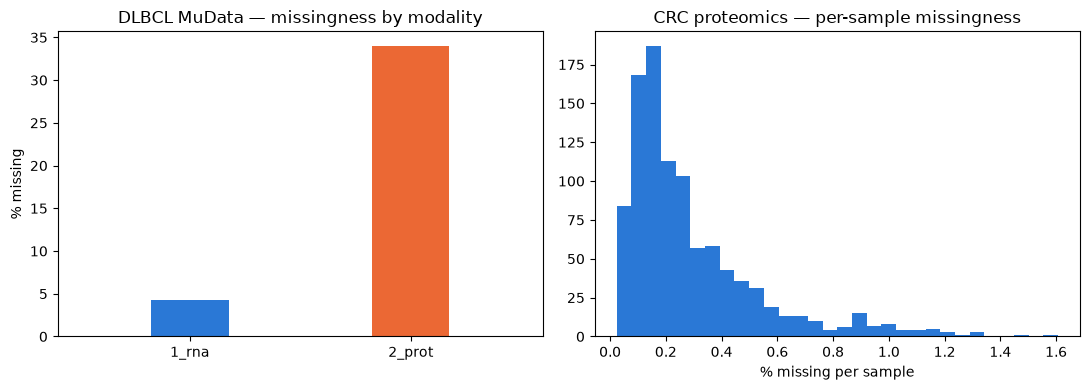

In [10]:
# --- Cell 10: quick missingness overview plots (aggregate, not per-sample) --
MODALITY_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # blue, orange, aqua, yellow

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# DLBCL: per-modality % missing as a bar chart
mod_names, mod_pct = [], []
for mod_name, adata in mdata.mod.items():
    if adata.X is not None:
        mod_names.append(mod_name)
        mod_pct.append(missingness_summary(adata.X)["pct_missing_overall"])
bar_colors = [MODALITY_COLORS[i % len(MODALITY_COLORS)] for i in range(len(mod_names))]
axes[0].bar(mod_names, mod_pct, width=0.35, color=bar_colors)
axes[0].set_ylabel("% missing")
axes[0].set_title("DLBCL MuData — missingness by modality")
axes[0].set_xlim(-0.6, len(mod_names) - 0.4)  # keep the narrower bars from floating in empty space


# CRC: histogram of per-sample % missing (no sample labels shown)
per_sample_missing = crc_df.isna().mean(axis=1) * 100
axes[1].hist(per_sample_missing, bins=30, color=MODALITY_COLORS[0])
axes[1].set_xlabel("% missing per sample")
axes[1].set_title("CRC proteomics — per-sample missingness")

plt.tight_layout()
plt.show()

### Saving a QC summary

We collect the aggregate missingness statistics gathered above into a single `qc_summary.json` — explicitly a summary of missingness, not the underlying data, so it can be shared, versioned, or referenced later without any confidentiality concern.

In [11]:
# --- Cell 11: save a QC/metadata summary (NOT raw data) for downstream use --
qc_summary = {
    "dlbcl_mudata": {
        mod_name: missingness_summary(adata.X)
        for mod_name, adata in mdata.mod.items()
        if adata.X is not None
    },
    "crc_proteomics_csv": crc_miss,
}

Path("qc_summary.json").write_text(json.dumps(qc_summary, indent=2))
print("wrote qc_summary.json")

wrote qc_summary.json


### Checking for structural missingness

Before settling on a benchmark design, it's worth asking whether either dataset contains rows or columns that are missing *entirely*. An entirely-missing feature or sample carries no signal for any imputer to learn from — there's nothing observed to compare a prediction against — so these cases need a deliberate decision rather than being silently absorbed into the benchmark. The cell below counts how many such rows and columns exist in each dataset; the next cell acts on what it finds.

In [12]:
# --- Cell 12: structural-missingness flags -------
# "All-missing" rows/columns carry zero signal — there's nothing for any
# imputer to learn from, so they need a decision before benchmarking:
# we can exclude them, or (for a whole sample missing one modality) treat it
# as a cross-modality prediction task; but MOFA-Flex's later can handle such problem 
# since it is a shared-factor model suited for such and a row-wise
# method like KNN/MissForest is not.

for mod_name, adata in mdata.mod.items():
    miss = missingness_summary(adata.X)
    n_obs_ = miss["shape"][0]
    print(
        f"DLBCL {mod_name}: {miss['n_samples_all_missing']}/{n_obs_} samples "
        f"fully missing, {miss['n_features_all_missing']} features fully missing "
        f"(overall {miss['pct_missing_overall']}%)"
    )

n_samples_ = crc_miss["shape"][0]
print(
    f"CRC proteomics: {crc_miss['n_samples_all_missing']}/{n_samples_} samples "
    f"fully missing, {crc_miss['n_features_all_missing']} features fully missing "
    f"(overall {crc_miss['pct_missing_overall']}%)"
)

DLBCL 1_rna: 14/332 samples fully missing, 0 features fully missing (overall 4.22%)
DLBCL 2_prot: 0/332 samples fully missing, 70 features fully missing (overall 34.01%)
CRC proteomics: 0/997 samples fully missing, 0 features fully missing (overall 0.29%)


### Resolving the two structural-missingness cases

The check above surfaces two distinct cases, and they call for different treatment.

The all-missing proteins in `2_prot` carry zero signal — there is nothing observed anywhere for them, so no imputer can be fairly evaluated on entries that were never measured in a single sample. These are dropped unconditionally before benchmarking.

The RNA-unprofiled samples are a different case. For a standard single-view benchmark — mask an observed value, impute it, compare to the truth — they contribute nothing either way, since only observed values can be masked in the first place. But they are a genuine instance of a real, harder problem: recovering an entire missing view from the other view. Rather than drop them, we flag them (`rna_profiled=False`) and keep them in the data, so a cross-modality method — MOFA-Flex chief among them, given its shared-factor design — can be evaluated on exactly this case later, in a way that a row-wise method like KNN or MissForest cannot.

In [13]:
# --- Cell 13: filter/flag the two structural-missingness cases from Cell 12 --
def to_dense(X):
    return X.toarray() if hasattr(X, "toarray") else X


prot = mdata.mod["2_prot"]
all_missing_proteins = prot.var_names[np.isnan(to_dense(prot.X)).all(axis=0)]
print(f"dropping {len(all_missing_proteins)} all-missing proteins from 2_prot")
mdata.mod["2_prot"] = prot[:, ~prot.var_names.isin(all_missing_proteins)].copy()

rna = mdata.mod["1_rna"]
rna_unprofiled = rna.obs_names[np.isnan(to_dense(rna.X)).all(axis=1)]
mdata.obs["rna_profiled"] = ~mdata.obs_names.isin(rna_unprofiled)
print(f"{len(rna_unprofiled)} samples flagged rna_profiled=False (kept, not dropped)")
print(mdata.obs["rna_profiled"].value_counts().to_dict())

mdata.update()  # resync shapes/union var after the 2_prot filtering
mdata

dropping 70 all-missing proteins from 2_prot
14 samples flagged rna_profiled=False (kept, not dropped)
{True: 318, False: 14}


MuData object with n_obs × n_vars = 332 × 27224
  obs:	'cell_of_origin', 'Lymphgen_Class_MYC', 'doub_trib_hit', 'OS_Followup_Y', 'OS_status', 'MHG', 'cluster_AIC', 'ICDO3', 'stromal_quantile_rank', 'prolif_quantile_rank', 'ecotype', 'rchop_real', 'rna_profiled'
  var:	'symbols'
  2 modalities
    1_rna:	332 × 20314
      var:	'symbols'
    2_prot:	332 × 6910
      var:	'symbols'

### Saving the cleaned data

We write one processed copy of each dataset here, so that `benchmark_imputation_clinicalv1.ipynb` doesn't need to re-derive the filtering above, or re-pay the cost of reading the full MuData object, every time it runs.

In [14]:
# --- Cell 14: save the cleaned data for the benchmarking notebook ------
# One processed copy, written once, so the benchmarking notebook doesn't
# need to re-derive the filtering above (and doesn't re-pay the h5mu read
# cost every run).
def resolve_output_dir(env_var="IMPUTATION_OUTPUT_DIR"):
    candidates = []
    if os.environ.get(env_var):
        candidates.append(Path(os.environ[env_var]).expanduser())
    candidates += [
        BASE_DIR / "data" / "processed",  # project root, e.g. /home/rnjue/Imputationv2/data/processed
        DLBCL_MUDATA_PATH.parent / "processed",  # try alongside the source data next, in case it's writable
        Path.home() / "reuben_imputation" / "processed",
        THIS_DIR / "processed",
    ]
    tried = []
    for d in candidates:
        tried.append(str(d))
        try:
            d.mkdir(parents=True, exist_ok=True)
            probe = d / ".write_test"
            probe.touch()
            probe.unlink()
            return d
        except (PermissionError, OSError):
            continue
    raise PermissionError(
        "No writable output location found among: " + ", ".join(tried) +
        f". Set the {env_var} environment variable to a directory you can write to."
    )


PROCESSED_DIR = resolve_output_dir()
print("processed dir (confirmed writable):", PROCESSED_DIR)

mdata.write(PROCESSED_DIR / "dlbcl_mudata_filtered.h5mu")
crc_df.to_csv(PROCESSED_DIR / "crc_proteomics_samples_x_features.csv")

print("wrote:", PROCESSED_DIR / "dlbcl_mudata_filtered.h5mu")
print("wrote:", PROCESSED_DIR / "crc_proteomics_samples_x_features.csv")

processed dir (confirmed writable): /home/rnjue/Imputationv2/data/processed


wrote: /home/rnjue/Imputationv2/data/processed/dlbcl_mudata_filtered.h5mu
wrote: /home/rnjue/Imputationv2/data/processed/crc_proteomics_samples_x_features.csv
